# 8-Metric Publication Figures for CTA, Headline, and Product

This notebook keeps the **same modern visual structure** as the single-metric plot you liked, but now:

- uses **all 8 gaze metrics**
- arranges them in a **4 × 2 grid**
- automatically creates **3 separate PDFs**
  1. CTA
  2. Headline
  3. Product

Each panel includes:
- raw image-level observations
- faint matched-image trajectories
- connected means across A–E
- mean ± 95% CI
- mean labels
- significant C-focused post-hoc brackets when available

### Input files

```text
data/A_to_E_long_image_level_data.csv
data/A_to_E_repeated_measures_posthoc.csv
```


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats


## 1. Configuration

In [2]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"
POSTHOC_CSV = "data/A_to_E_repeated_measures_posthoc.csv"

CONDITION_ORDER = ["A", "B", "C", "D", "E"]

AOIS = [
    "CTA",
    "Headline",
    "Product",
]

# All 8 metrics
SELECTED_METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

# Show only C-focused pairwise comparisons if significant
SIGNIFICANCE_PAIRS = [
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("C", "E"),
]

SHOW_MATCHED_LINES = True
SHOW_MEAN_LABELS = True

RANDOM_SEED = 42


## 2. Load data

In [3]:
for f in [LONG_CSV, POSTHOC_CSV]:
    if not Path(f).exists():
        raise FileNotFoundError(
            f"Could not find {f}. Check the path in the configuration cell."
        )

long_df = pd.read_csv(LONG_CSV)
posthoc = pd.read_csv(POSTHOC_CSV)

for frame in [long_df, posthoc]:
    frame.columns = [
        str(c).replace("**", "").strip()
        for c in frame.columns
    ]

long_df["value"] = pd.to_numeric(
    long_df["value"],
    errors="coerce"
)

print("Available AOIs:", sorted(long_df["AOI"].dropna().unique()))
print("Available metrics:", sorted(long_df["metric"].dropna().unique()))
print("Rows:", len(long_df))


Available AOIs: ['CTA', 'Headline', 'Product']
Available metrics: ['FFD (s)', 'Fix. duration (s)', 'Fixations', 'K-coefficient', 'Revisits', 'TTFF (s)', 'Time spent (s)', 'VAI (%)']
Rows: 2400


## 3. Validate all 8 metrics

In [4]:
available_metrics = set(
    long_df["metric"].dropna().unique()
)

missing_metrics = [
    m for m in SELECTED_METRICS
    if m not in available_metrics
]

if missing_metrics:
    raise ValueError(
        f"These metrics are missing from the long dataset: {missing_metrics}"
    )

available_aois = set(
    long_df["AOI"].dropna().unique()
)

missing_aois = [
    a for a in AOIS
    if a not in available_aois
]

if missing_aois:
    raise ValueError(
        f"These AOIs are missing from the long dataset: {missing_aois}"
    )

print("Validation passed.")


Validation passed.


## 4. Helper functions

In [5]:
def get_focus(aoi, metric):
    df = long_df[
        (long_df["AOI"] == aoi)
        & (long_df["metric"] == metric)
        & (long_df["condition"].isin(CONDITION_ORDER))
    ].copy()

    df = df.dropna(subset=["value"])
    return df


def get_summary(focus_df):
    rows = []

    for cond in CONDITION_ORDER:
        vals = (
            focus_df.loc[
                focus_df["condition"] == cond,
                "value"
            ]
            .dropna()
            .astype(float)
            .values
        )

        n = len(vals)

        if n == 0:
            mean = np.nan
            sd = np.nan
            ci = np.nan
        else:
            mean = np.mean(vals)
            sd = np.std(vals, ddof=1) if n > 1 else np.nan

            if n > 1:
                se = sd / np.sqrt(n)
                tcrit = stats.t.ppf(
                    0.975,
                    df=n - 1
                )
                ci = tcrit * se
            else:
                ci = np.nan

        rows.append({
            "condition": cond,
            "n": n,
            "mean": mean,
            "sd": sd,
            "ci95": ci,
            "lower": mean - ci if np.isfinite(ci) else np.nan,
            "upper": mean + ci if np.isfinite(ci) else np.nan,
        })

    return pd.DataFrame(rows)


def get_pivot(focus_df):
    return (
        focus_df
        .pivot(
            index="Img",
            columns="condition",
            values="value"
        )
        .reindex(columns=CONDITION_ORDER)
    )


def get_pair_row(aoi, metric, g1, g2):
    mask = (
        (posthoc["AOI"] == aoi)
        & (posthoc["metric"] == metric)
        & (
            (
                (posthoc["group1"] == g1)
                & (posthoc["group2"] == g2)
            )
            |
            (
                (posthoc["group1"] == g2)
                & (posthoc["group2"] == g1)
            )
        )
    )

    rows = posthoc.loc[mask]

    if len(rows) == 0:
        return None

    return rows.iloc[0]


def format_q(q):
    if pd.isna(q):
        return ""

    if q < 0.001:
        return "q < .001"

    return f"q = {q:.3f}"


def deterministic_jitter(n, width=0.085):
    if n <= 1:
        return np.zeros(n)

    return np.linspace(
        -width,
        width,
        n
    )


def get_ylabel(metric):
    labels = {
        "VAI (%)": "VAI (%)",
        "TTFF (s)": "TTFF (s)",
        "Time spent (s)": "Time spent (s)",
        "Fixations": "Fixations",
        "Fix. duration (s)": "Fix. duration (s)",
        "FFD (s)": "FFD (s)",
        "K-coefficient": "K-coefficient",
        "Revisits": "Revisits",
    }

    return labels.get(metric, metric)


## 5. Function to draw one metric panel

In [6]:
def draw_metric_panel(
    ax,
    aoi,
    metric,
    panel_index,
    condition_colors
):
    focus = get_focus(
        aoi,
        metric
    )

    if focus.empty:
        ax.set_visible(False)
        return

    summary = get_summary(focus)
    pivot = get_pivot(focus)

    x_positions = {
        c: i
        for i, c in enumerate(CONDITION_ORDER)
    }

    # --------------------------------------------------
    # Subtle emphasis around C
    # --------------------------------------------------
    c_x = x_positions["C"]

    ax.axvspan(
        c_x - 0.34,
        c_x + 0.34,
        alpha=0.035,
        zorder=0
    )

    # --------------------------------------------------
    # Matched-image trajectories
    # --------------------------------------------------
    if SHOW_MATCHED_LINES:
        complete = pivot.dropna()

        for _, row in complete.iterrows():
            ax.plot(
                np.arange(
                    len(CONDITION_ORDER)
                ),
                row[
                    CONDITION_ORDER
                ].astype(float).values,
                linewidth=0.50,
                alpha=0.055,
                zorder=1
            )

    # --------------------------------------------------
    # Raw observations
    # --------------------------------------------------
    rng = np.random.default_rng(
        RANDOM_SEED + panel_index
    )

    for cond in CONDITION_ORDER:
        vals = (
            focus.loc[
                focus["condition"] == cond,
                "value"
            ]
            .dropna()
            .astype(float)
            .sort_values()
            .values
        )

        x0 = x_positions[cond]

        jitter = deterministic_jitter(
            len(vals),
            width=0.080
        )

        if len(jitter) > 1:
            jitter = jitter[
                rng.permutation(
                    len(jitter)
                )
            ]

        ax.scatter(
            np.full(
                len(vals),
                x0
            ) + jitter,
            vals,
            s=23,
            alpha=0.44,
            color=condition_colors[cond],
            edgecolors="white",
            linewidths=0.38,
            zorder=3
        )

    # --------------------------------------------------
    # Mean trajectory
    # --------------------------------------------------
    mean_values = [
        summary.loc[
            summary["condition"] == c,
            "mean"
        ].iloc[0]
        for c in CONDITION_ORDER
    ]

    ax.plot(
        np.arange(
            len(CONDITION_ORDER)
        ),
        mean_values,
        linewidth=2.15,
        alpha=0.88,
        zorder=4,
        path_effects=[
            pe.Stroke(
                linewidth=3.7,
                foreground="white"
            ),
            pe.Normal()
        ]
    )

    # --------------------------------------------------
    # Means + 95% CI
    # --------------------------------------------------
    for _, r in summary.iterrows():
        cond = r["condition"]
        x = x_positions[cond]

        ax.errorbar(
            x,
            r["mean"],
            yerr=r["ci95"],
            fmt="o",
            markersize=7.3,
            capsize=4.2,
            capthick=1.2,
            elinewidth=1.7,
            color=condition_colors[cond],
            markeredgecolor="white",
            markeredgewidth=0.95,
            zorder=6
        )

    # --------------------------------------------------
    # Panel range
    # --------------------------------------------------
    data_min = float(
        focus["value"].min()
    )

    data_max = float(
        focus["value"].max()
    )

    data_range = max(
        1e-6,
        data_max - data_min
    )

    # --------------------------------------------------
    # Mean labels
    # --------------------------------------------------
    if SHOW_MEAN_LABELS:
        for _, r in summary.iterrows():
            if not np.isfinite(r["mean"]):
                continue

            cond = r["condition"]
            x = x_positions[cond]

            label_y = (
                r["upper"]
                if np.isfinite(r["upper"])
                else r["mean"]
            )

            ax.text(
                x,
                label_y
                + 0.020 * data_range,
                f'{r["mean"]:.2f}'
                if abs(r["mean"]) < 10
                else f'{r["mean"]:.1f}',
                ha="center",
                va="bottom",
                fontsize=7.0,
                fontweight="bold",
                color=condition_colors[cond],
                zorder=7,
                bbox=dict(
                    boxstyle="round,pad=0.14",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.88
                )
            )

    # --------------------------------------------------
    # Significant post-hoc brackets
    # --------------------------------------------------
    sig_pairs = []

    for g1, g2 in SIGNIFICANCE_PAIRS:
        row = get_pair_row(
            aoi,
            metric,
            g1,
            g2
        )

        if row is None:
            continue

        q = pd.to_numeric(
            pd.Series([
                row.get(
                    "q_posthoc_global_FDR"
                )
            ]),
            errors="coerce"
        ).iloc[0]

        sig = bool(
            row.get(
                "significant_posthoc_global_FDR",
                False
            )
        )

        if sig and np.isfinite(q):
            sig_pairs.append(
                (
                    g1,
                    g2,
                    q
                )
            )

    base_y = (
        data_max
        + 0.085 * data_range
    )

    step = (
        0.065 * data_range
    )

    bracket_h = (
        0.013 * data_range
    )

    for k, (
        g1,
        g2,
        q
    ) in enumerate(sig_pairs):

        x1 = x_positions[g1]
        x2 = x_positions[g2]

        y = (
            base_y
            + k * step
        )

        ax.plot(
            [
                x1,
                x1,
                x2,
                x2
            ],
            [
                y,
                y + bracket_h,
                y + bracket_h,
                y
            ],
            linewidth=0.95,
            zorder=8
        )

        ax.text(
            (
                x1 + x2
            ) / 2,
            y
            + bracket_h
            + 0.006 * data_range,
            format_q(q),
            ha="center",
            va="bottom",
            fontsize=6.5,
            bbox=dict(
                boxstyle="round,pad=0.14",
                facecolor="white",
                edgecolor="none",
                alpha=0.96
            ),
            zorder=9
        )

    # --------------------------------------------------
    # Axes limits
    # --------------------------------------------------
    upper_limit = (
        base_y
        + max(
            1,
            len(sig_pairs)
        ) * step
        + 0.070 * data_range
    )

    lower_limit = (
        data_min
        - 0.040 * data_range
    )

    ax.set_ylim(
        lower_limit,
        upper_limit
    )

    # --------------------------------------------------
    # Panel styling
    # --------------------------------------------------
    ax.set_title(
        metric,
        loc="left",
        fontweight="bold",
        fontsize=10.8,
        pad=8
    )

    matched_n = len(
        pivot.dropna()
    )

    ax.text(
        0,
        1.004,
        f"matched images n = {matched_n}",
        transform=ax.transAxes,
        fontsize=7.2,
        va="bottom",
        alpha=0.64
    )

    ax.set_ylabel(
        get_ylabel(metric),
        fontsize=8.8
    )

    ax.set_xticks(
        np.arange(
            len(CONDITION_ORDER)
        )
    )

    ax.set_xticklabels(
        CONDITION_ORDER,
        fontweight="bold",
        fontsize=8.5
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.spines[
        "left"
    ].set_alpha(0.42)

    ax.spines[
        "bottom"
    ].set_alpha(0.42)

    ax.grid(
        axis="y",
        linewidth=0.5,
        alpha=0.09
    )

    ax.grid(
        axis="x",
        visible=False
    )

    ax.tick_params(
        axis="both",
        length=0
    )


## 6. Function to create one 8-metric PDF

In [7]:
def create_aoi_figure(aoi):

    plt.rcParams.update({
        "font.size": 9,
        "axes.titlesize": 10.8,
        "axes.labelsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 0.75,
    })

    cycle_colors = (
        plt.rcParams[
            "axes.prop_cycle"
        ]
        .by_key()
        .get(
            "color",
            []
        )
    )

    if len(
        cycle_colors
    ) < len(
        CONDITION_ORDER
    ):
        cycle_colors = [
            f"C{i}"
            for i in range(
                len(
                    CONDITION_ORDER
                )
            )
        ]

    condition_colors = {
        c: cycle_colors[i]
        for i, c
        in enumerate(
            CONDITION_ORDER
        )
    }

    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=(
            12.8,
            17.2
        )
    )

    axes = (
        axes
        .flatten()
    )

    for i, metric in enumerate(
        SELECTED_METRICS
    ):
        draw_metric_panel(
            axes[i],
            aoi,
            metric,
            panel_index=i,
            condition_colors=condition_colors
        )

    # x-axis title only on bottom row
    for i, ax in enumerate(axes):
        if i < 6:
            ax.set_xlabel("")
        else:
            ax.set_xlabel(
                "Condition",
                fontsize=9
            )

    fig.suptitle(
        f"{aoi} gaze metrics across conditions A–E",
        x=0.065,
        y=0.995,
        ha="left",
        fontsize=17,
        fontweight="bold"
    )

    fig.text(
        0.065,
        0.980,
        (
            "Image-level gaze responses · raw observations · "
            "matched-image trajectories · mean ± 95% CI · "
            "FDR-significant C-focused post-hoc comparisons"
        ),
        fontsize=9.5,
        alpha=0.70
    )

    fig.tight_layout(
        rect=[
            0.035,
            0.035,
            0.995,
            0.965
        ],
        h_pad=2.4,
        w_pad=2.0
    )

    output_png = (
        f"{aoi}_8metrics_modern.png"
    )

    output_pdf = (
        f"{aoi}_8metrics_modern.pdf"
    )

    fig.savefig(
        output_png,
        dpi=500,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        output_pdf,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    print(
        "Saved:",
        output_png
    )

    print(
        "Saved:",
        output_pdf
    )

    return output_pdf


## 7. Generate the 3 PDFs automatically


Creating figure for: CTA


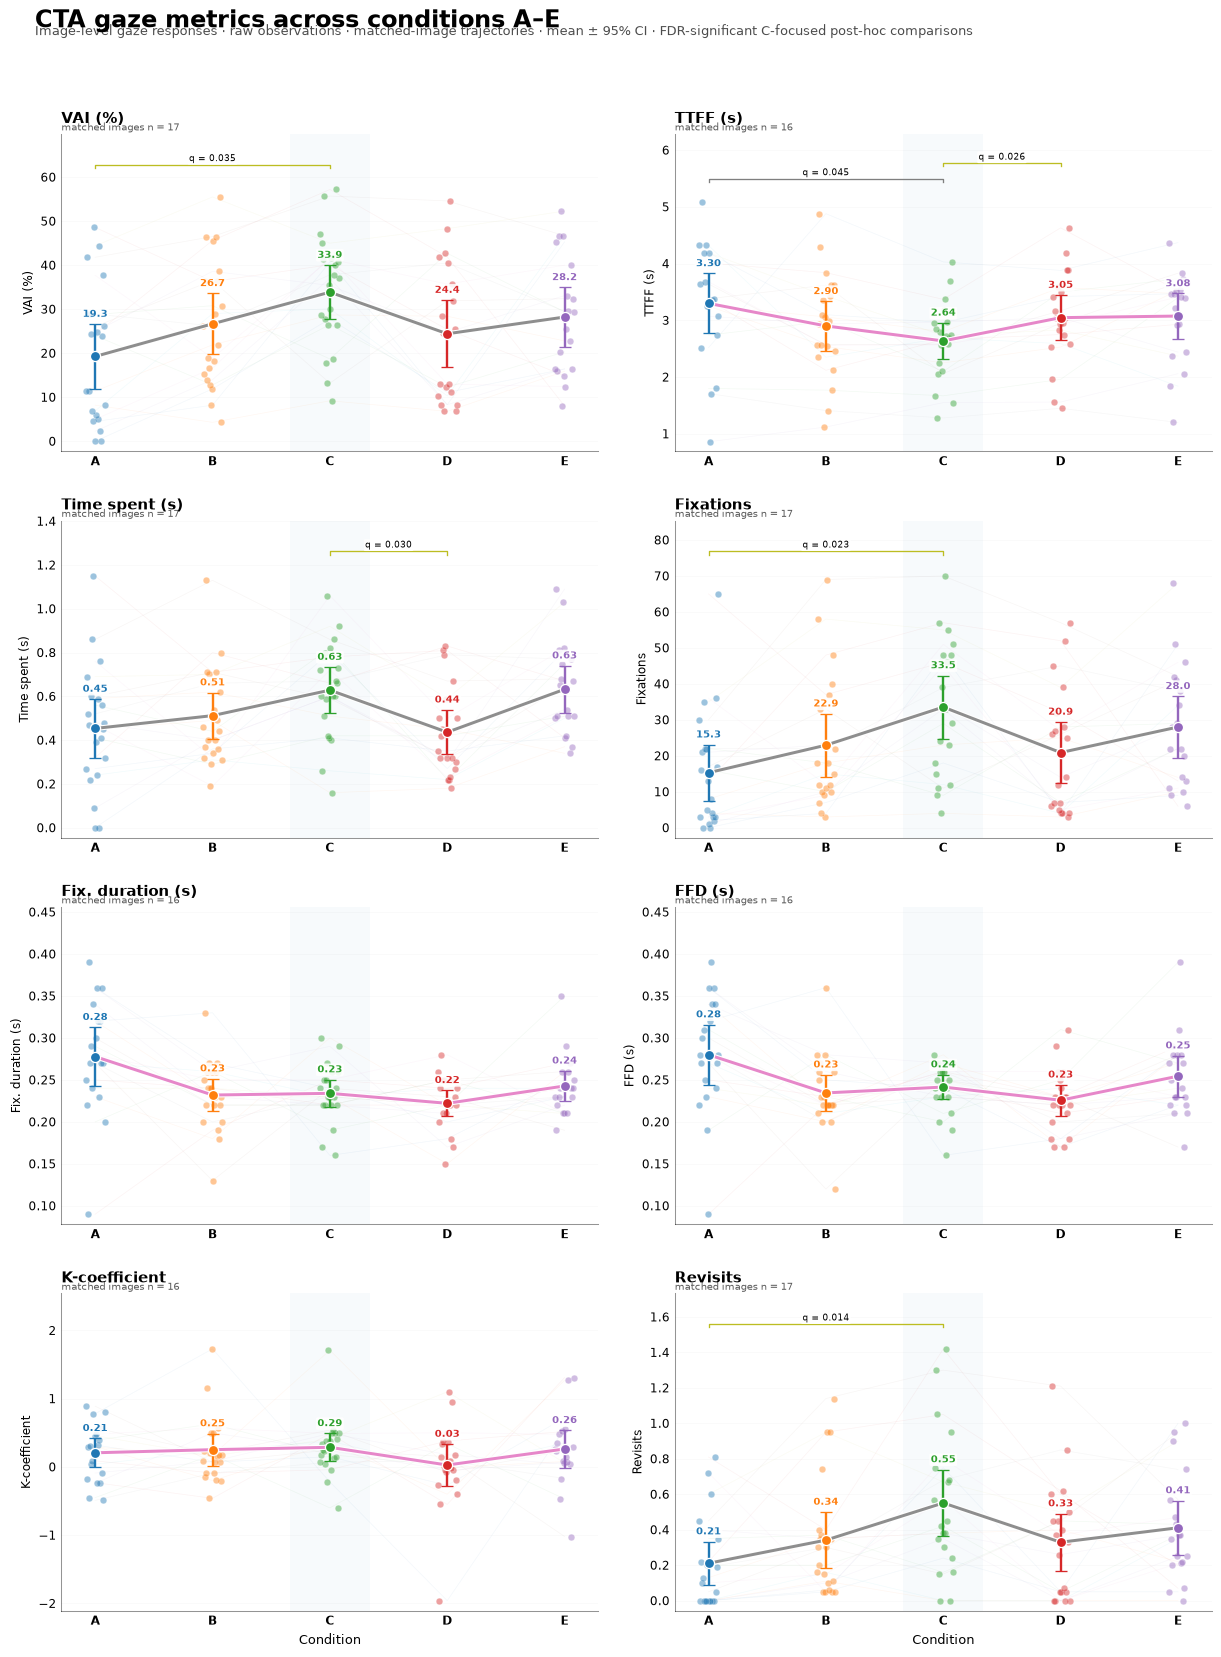

Saved: CTA_8metrics_modern.png
Saved: CTA_8metrics_modern.pdf

Creating figure for: Headline


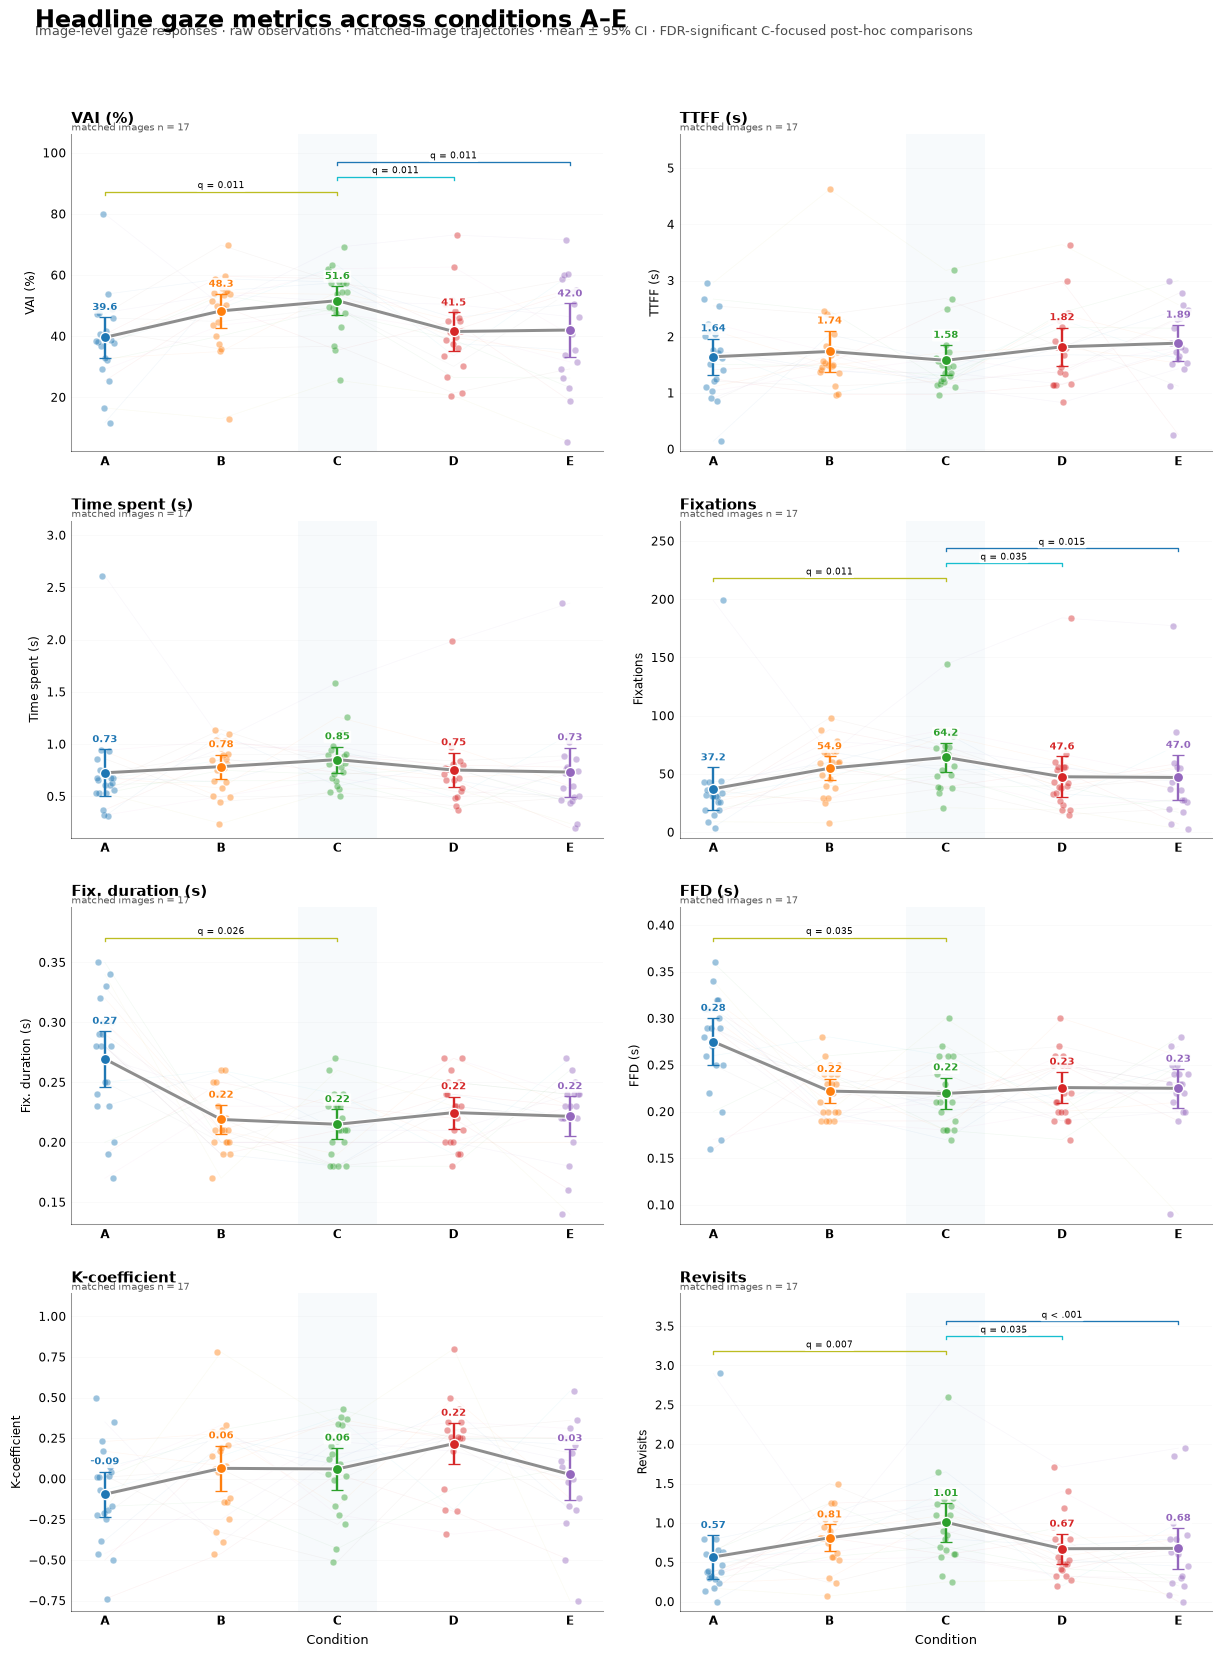

Saved: Headline_8metrics_modern.png
Saved: Headline_8metrics_modern.pdf

Creating figure for: Product


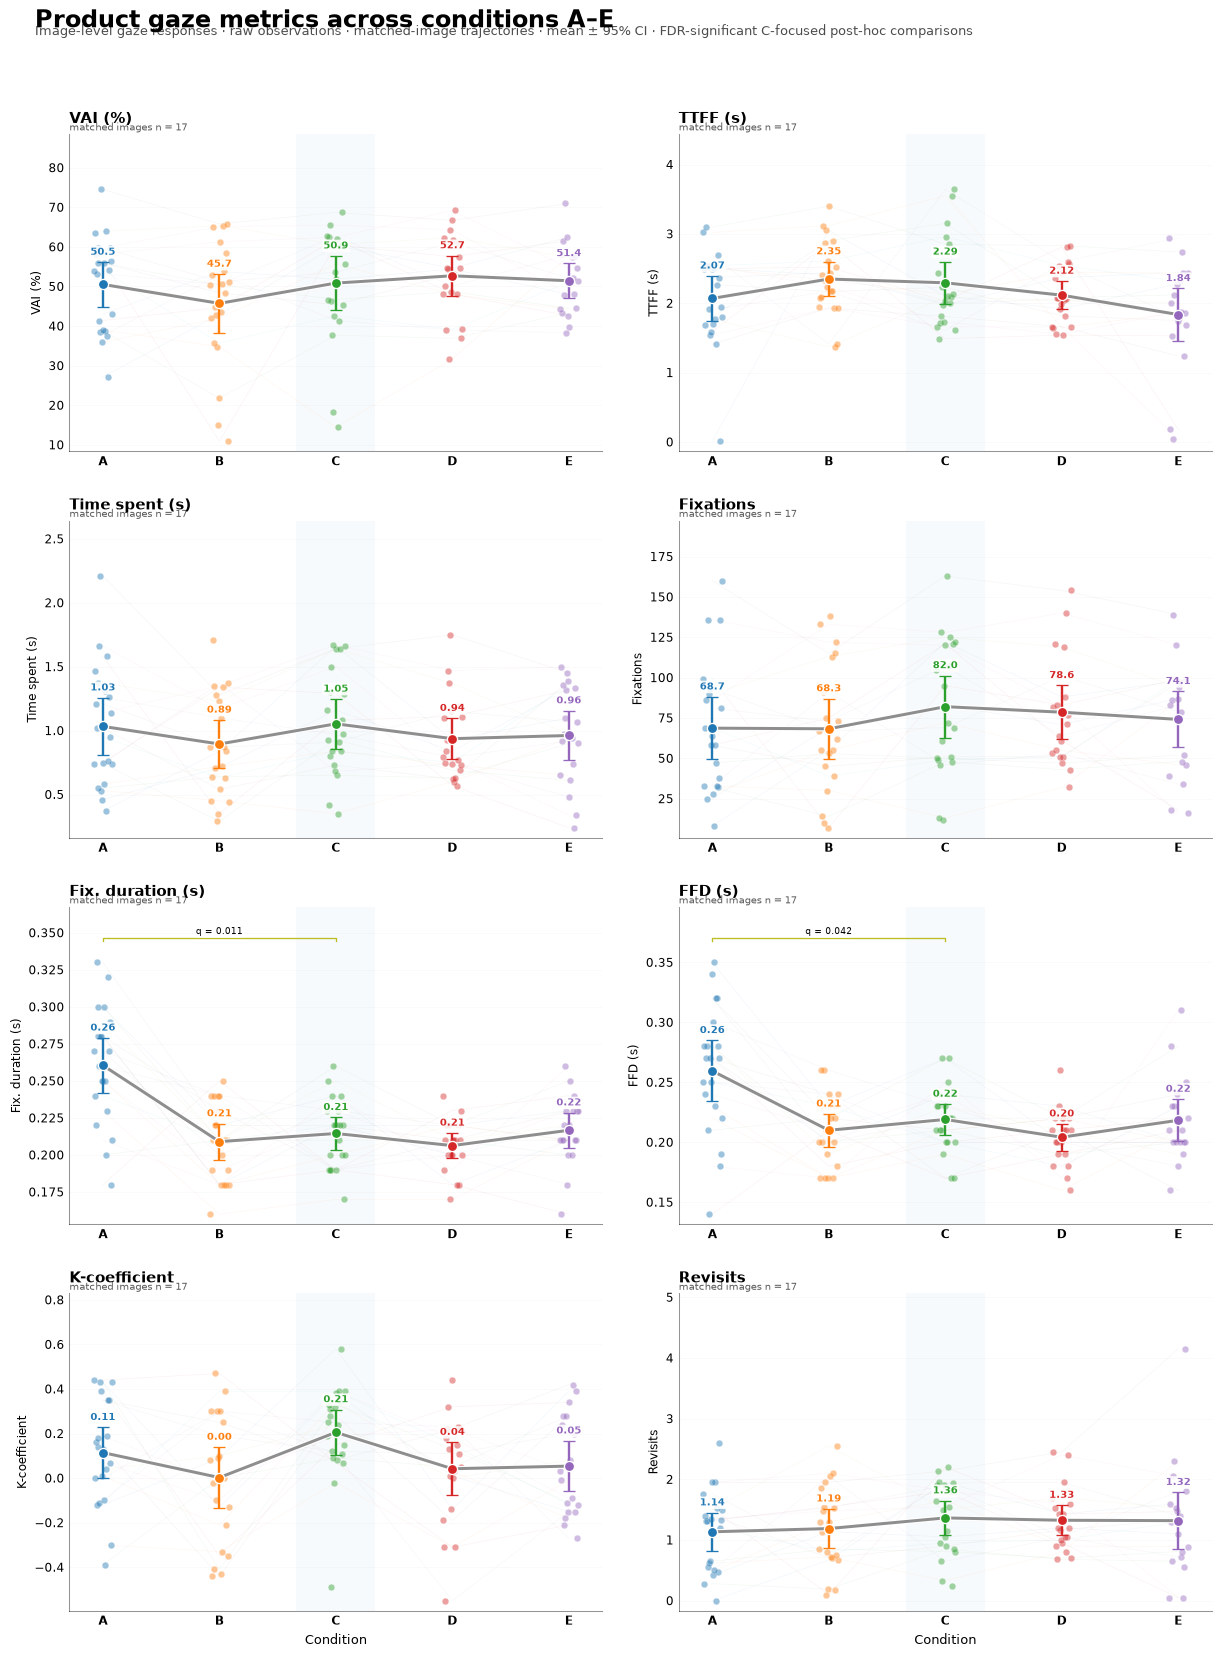

Saved: Product_8metrics_modern.png
Saved: Product_8metrics_modern.pdf

Generated PDFs:
- CTA_8metrics_modern.pdf
- Headline_8metrics_modern.pdf
- Product_8metrics_modern.pdf


In [8]:
generated_pdfs = []

for aoi in AOIS:
    print("\nCreating figure for:", aoi)

    generated_pdfs.append(
        create_aoi_figure(
            aoi
        )
    )

print("\nGenerated PDFs:")
for f in generated_pdfs:
    print("-", f)


## Outputs

Running the final cell creates:

```text
CTA_8metrics_modern.pdf
Headline_8metrics_modern.pdf
Product_8metrics_modern.pdf
```

and corresponding high-resolution PNG files.

Each PDF contains all **8 metrics in a 4 × 2 layout** using the same design.
